### Cleaning & EDA

Goals : Normalize audio features, resample per-game for uniform distribution, run EDA (correlations and plots), and save per-game summaries.

> Now that we've gotten the data through Steam API then RapidAPI, we're gonna perform some data cleaning !

In [2]:
import pandas as pd
# Either take the cached one or the final version on rapidapi_features.csv
df = pd.read_csv('../data/rapidapi_cache.csv')

print('Rows loaded:', len(df))

# We're gonna drop appid for now as it isn't very useful for us
if 'appid' in df.columns:
    df = df.drop(columns=['appid'])

MUSIC_INFO = ['danceability','energy','valence','acousticness','instrumentalness','liveness','speechiness','tempo']

for c in MUSIC_INFO:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

before = df.shape[0]
df = df.dropna(subset=[col for col in ['danceability','energy','tempo'] if col in df.columns])
df = df.dropna(subset=['spotify_track_id'])

print('Dropped', before - df.shape[0], 'rows missing core features or spotify id')

if 'spotify_track_id' in df.columns:
    df = df.drop_duplicates(subset=['spotify_track_id']).reset_index(drop=True)

print('DataFrame rows after cleaning and dedupe :', df.shape[0])

out_path = '../data/rapidapi_features_clean.csv'

df.to_csv(out_path, index=False),

print(f'Saved cleaned features to {out_path}')

Rows loaded: 820
Dropped 67 rows missing core features or spotify id
DataFrame rows after cleaning and dedupe : 753
Saved cleaned features to ../data/rapidapi_features_clean.csv


> Let's now normalize the audio feature columns to a 0–1 range (min-max scaling) so similarity calculations behave consistently.

In [3]:
# We'll do a simple min-max scaling
MUSIC_INFO = ['danceability','energy','valence','acousticness','instrumentalness','liveness','speechiness','tempo']
num_cols = [c for c in MUSIC_INFO if c in df.columns]
for c in num_cols:
    minv = df[c].min()
    maxv = df[c].max()
    if pd.isna(minv) or maxv == minv:
        continue
    df[c] = (df[c] - minv) / (maxv - minv)

print('Scaled columns:', num_cols)
out_scaled = '../data/rapidapi_features_scaled.csv'
df.to_csv(out_scaled, index=False)
print(f'Saved scaled features to {out_scaled}')

Scaled columns: ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'tempo']
Saved scaled features to ../data/rapidapi_features_scaled.csv


In [4]:
df.value_counts(subset="game_title")

game_title
Stardew Valley                                      48
Danganronpa 2: Goodbye Despair                      47
Detroit: Become Human                               44
Danganronpa V3: Killing Harmony                     43
Genshin Impact                                      41
Danganronpa Another Episode: Ultra Despair Girls    41
We Were Here Forever                                31
Dead by Daylight                                    28
Gang Beasts                                         27
Date Everything!                                    27
PEAK                                                27
Where Winds Meet                                    26
Overwatch                                           25
The Last of Us™ Part I                              25
Stray                                               25
Five Nights at Freddy's 2                           21
The Awesome Adventures of Captain Spirit            19
Splatoon                                            18

> In most of the cases and due to possible errors during the transmission of the data, you'll have non-uniform distribution.

> We have 2 strategies : Either target the games/songs you like the most and do more API calls from different albums. Or if you want a model that bases his recommendation equally based on all your games and you don't want to have more API calls we can just use a resampling strategy.

> Here for my analysis I'll do an upsampling to have a uniform distribution !

> A uniform distribution ensures that every group contributes equally to the analysis or model, preventing a few massive groups from dominating and drowning out the insights of smaller ones.

In [5]:
target_count = df.value_counts(subset="game_title").max()
df_upsampled = df.groupby("game_title").sample(n=target_count, replace=True, random_state=42)
df_upsampled.value_counts(subset="game_title")


game_title
Among Us                                            48
The Awesome Adventures of Captain Spirit            48
Marvel Rivals                                       48
Overwatch                                           48
PEAK                                                48
Red Dead Redemption 2                               48
Splatoon                                            48
Stardew Valley                                      48
Stray                                               48
The Last of Us™ Part I                              48
Animal Crossing: New Horizons                       48
The Sims™ 4                                         48
Ultimate Chicken Horse                              48
Unrailed!                                           48
Until Dawn™                                         48
We Were Here Expeditions: The FriendShip            48
We Were Here Forever                                48
Where Winds Meet                                    48

> EDA rapide :

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_title        753 non-null    object 
 1   album_name        753 non-null    object 
 2   spotify_track_id  753 non-null    object 
 3   track_name        753 non-null    object 
 4   danceability      753 non-null    float64
 5   energy            753 non-null    float64
 6   valence           751 non-null    float64
 7   acousticness      753 non-null    float64
 8   instrumentalness  753 non-null    float64
 9   liveness          753 non-null    float64
 10  speechiness       753 non-null    float64
 11  tempo             753 non-null    float64
dtypes: float64(8), object(4)
memory usage: 70.7+ KB


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo
count,753.000000,753.000000,751.000000,753.000000,753.000000,753.000000,753.000000,753.000000
mean,0.455897,0.457583,0.313140,0.441979,0.654024,0.146053,0.057808,0.432950
std,0.226333,0.314875,0.290653,0.393337,0.336170,0.150227,0.088691,0.185166
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.267442,0.190000,0.052632,0.020000,0.460000,0.065934,0.029412,0.285714
50%,0.488372,0.410000,0.221053,0.400000,0.820000,0.076923,0.029412,0.434286
75%,0.627907,0.750000,0.526316,0.870000,0.910000,0.153846,0.058824,0.548571
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


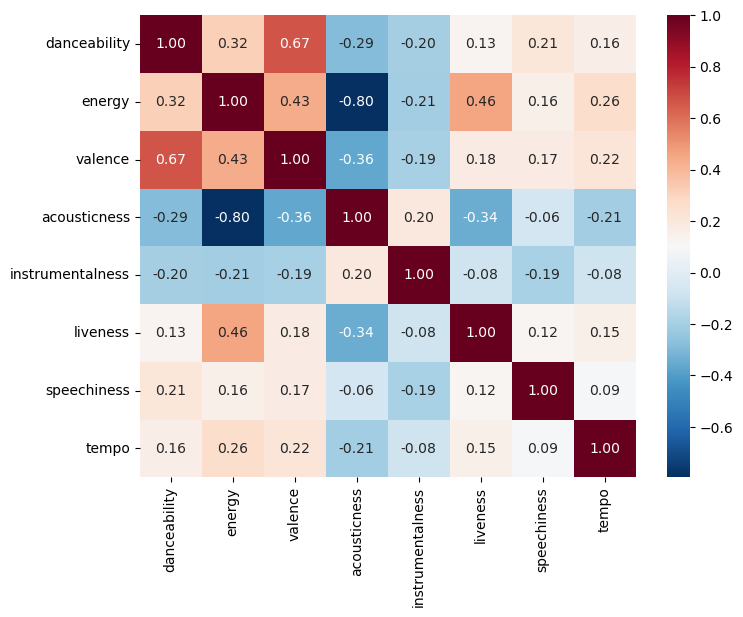

In [7]:
corr = df[["danceability","energy","valence","acousticness","instrumentalness","liveness","speechiness","tempo"]].corr()
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r")
plt.show()

<Axes: title={'center': 'tempo'}, xlabel='game_title'>

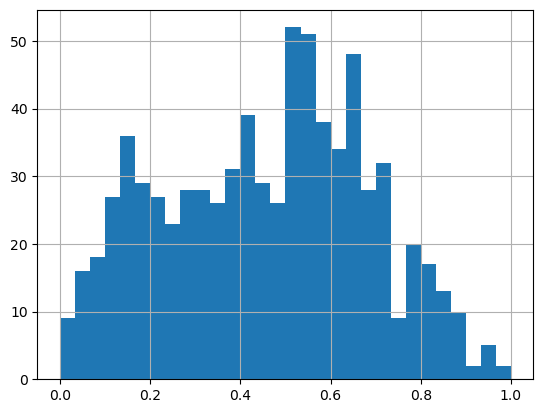

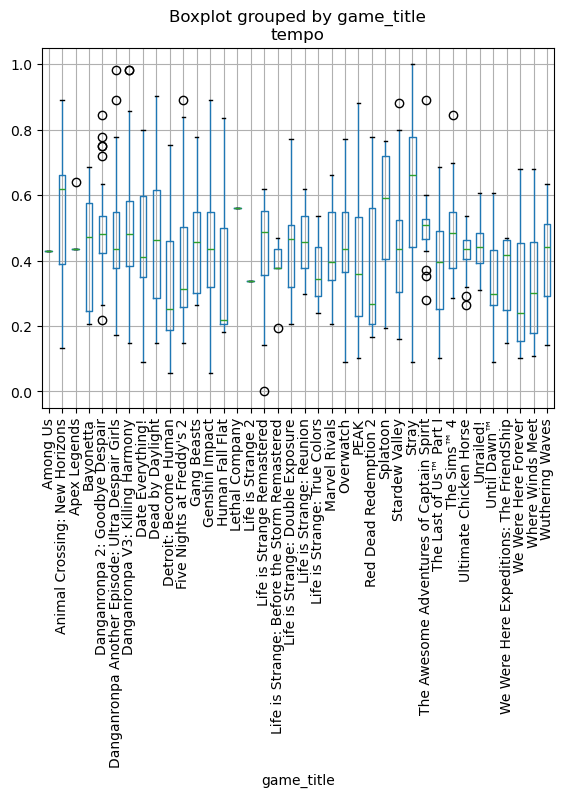

In [8]:
df["danceability"].hist(bins=30)
df.boxplot(column="tempo", by="game_title", rot=90)

> After the boxplot, summarize each game with a small per-game feature table so we can compare mood signatures more cleanly.

In [9]:
summary_cols = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'tempo']
per_game = df.groupby('game_title')[summary_cols].agg(['count', 'mean']).round(3)
per_game

danceability        energy  \
                                                        count   mean  count   
game_title                                                                    
Among Us                                                    1  0.395      1   
Animal Crossing: New Horizons                              14  0.749     14   
Apex Legends                                                5  0.474      5   
Bayonetta                                                  12  0.365     12   
Danganronpa 2: Goodbye Despair                             47  0.524     47   
Danganronpa Another Episode: Ultra Despair Girls           41  0.560     41   
Danganronpa V3: Killing Harmony                            43  0.501     43   
Date Everything!                                           27  0.655     27   
Dead by Daylight                                           28  0.362     28   
Detroit: Become Human                                      44  0.205     44   
Five Nights at Freddy's 2                                  21  0.272     21   
Gang Beasts                                                27  0.619     27   
Genshin Impact                                             41  0.366     41   
Human Fall Flat                                             8  0.387      8   
Lethal Company                                              1  0.547      1   
Life is Strange 2                                           1  0.314      1   
Life is Strange Remastered                                 12  0.431     12   
Life is Strange: Before the Storm Remastered                5  0.549      5   
Life is Strange: Double Exposure                           10  0.414     10   
Life is Strange: Reunion                                    2  0.186      2   
Life is Strange: True Colors                                3  0.605      3   
Marvel Rivals                                              16  0.408     16   
Overwatch                                                  25  0.328     25   
PEAK                                                       27  0.298     27   
Red Dead Redemption 2                                      13  0.433     13   
Splatoon                                                   18  0.614     18   
Stardew Valley                                             48  0.633     48   
Stray                                                      25  0.340     25   
The Awesome Adventures of Captain Spirit                   19  0.676     19   
The Last of Us™ Part I                                     25  0.361     25   
The Sims™ 4                                                17  0.515     17   
Ultimate Chicken Horse                                     13  0.723     13   
Unrailed!                                                  14  0.786     14   
Until Dawn™                                                18  0.365     18   
We Were Here Expeditions: The FriendShip                   11  0.487     11   
We Were Here Forever                                       31  0.259     31   
Where Winds Meet                                           26  0.353     26   
Wuthering Waves                                            14  0.398     14   

                                                        valence         \
                                                   mean   count   mean   
game_title                                                               
Among Us                                          0.630       1  0.684   
Animal Crossing: New Horizons                     0.170      14  0.573   
Apex Legends                                      0.440       5  0.069   
Bayonetta                                         0.562      12  0.375   
Danganronpa 2: Goodbye Despair                    0.902      47  0.497   
Danganronpa Another Episode: Ultra Despair Girls  0.790      41  0.431   
Danganronpa V3: Killing Harmony                   0.765      42  0.464   
Date Everything!                                  0.410      27  0.56

> To make this reproducible, we'll put the cleaning and scaling steps in one small function so we can rerun everything whenever needed.

In [10]:
def run_pipeline():
    df = pd.read_csv('../data/rapidapi_cache.csv')

    if 'appid' in df.columns:
        df = df.drop(columns=['appid'])

    music_info = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'tempo']
    for c in music_info:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    if 'valence' in df.columns:
        df['valence'] = df['valence'].fillna(df['valence'].median())

    df = df.dropna(subset=[c for c in ['danceability', 'energy', 'tempo'] if c in df.columns])
    df = df.dropna(subset=['spotify_track_id'])
    df = df.drop_duplicates(subset=['spotify_track_id']).reset_index(drop=True)

    df.to_csv('../data/rapidapi_features_clean.csv', index=False)
    df.to_parquet('../data/rapidapi_features_clean.parquet', index=False)

    df_scaled = df.copy()
    for c in music_info:
        if c in df_scaled.columns:
            minv = df_scaled[c].min()
            maxv = df_scaled[c].max()
            if pd.notna(minv) and maxv != minv:
                df_scaled[c] = (df_scaled[c] - minv) / (maxv - minv)

    df_scaled.to_csv('../data/rapidapi_features_scaled.csv', index=False)

    per_game = df.groupby('game_title')[music_info].agg(['count', 'mean']).round(3)
    per_game.to_csv('../data/per_game_summary.csv')

    print('Clean rows:', len(df))
    print('Games:', df['game_title'].nunique())
    print('Saved cleaned, scaled, and per-game summary files')

    return df, df_scaled, per_game

clean_df, scaled_df, per_game = run_pipeline()

Clean rows: 753
Games: 38
Saved cleaned, scaled, and per-game summary files
